<a href="https://colab.research.google.com/github/rayvankaazrifany/Tugas-Besar-NLP/blob/main/NLP_SentimentClassificationRoBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

file_path = 'dataset_pizza_cleaned.xlsx'
df = pd.read_excel(file_path)

print(f"File '{file_path}' berhasil dibaca ke dalam DataFrame 'df'. Berikut 5 baris pertamanya:")
print(df.head())

File 'dataset_pizza_cleaned.xlsx' berhasil dibaca ke dalam DataFrame 'df'. Berikut 5 baris pertamanya:
  cabang                                             ulasan
0   Dago            pizzanya enak, penasaran coba menu lain
1   Dago                         makanan enak pelayanan oke
2   Dago                   Menarik mas nya ramah pizza enak
3   Dago  Pizza nya enak, lembut dan kriuk, tidak alot\n...
4   Dago                                     best cheeseeee


In [ ]:
import pandas as pd
from transformers import pipeline

# Install transformers if not already installed
try:
    import transformers
except ImportError:
    !pip install transformers
    import transformers

# Load the sentiment analysis pipeline
sentiment_classifier = pipeline(
    'sentiment-analysis',
    model='w11wo/indonesian-roberta-base-sentiment-classifier'
)

# Define a function to get sentiment label only
def get_sentiment(text):
    if pd.isna(text) or text == '':
        return None  # Handle empty or NaN text
    try:
        result = sentiment_classifier(text)[0]
        return result['label']
    except Exception as e:
        print(f"Error processing text: {text} - {e}")
        return None

# Apply the sentiment analysis to the 'ulasan' column, simpan ke kolom 'sentiment'
df['sentiment'] = df['ulasan'].apply(get_sentiment)

print("Sentiment labeling selesai. Berikut adalah 5 baris pertama dengan kolom sentimen baru:")
print(df.head())

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Sentiment labeling selesai. Berikut adalah 5 baris pertama dengan kolom sentimen baru:
  cabang                                             ulasan sentiment
0   Dago            pizzanya enak, penasaran coba menu lain  positive
1   Dago                         makanan enak pelayanan oke  positive
2   Dago                   Menarik mas nya ramah pizza enak  positive
3   Dago  Pizza nya enak, lembut dan kriuk, tidak alot\n...  positive
4   Dago                                     best cheeseeee  negative


In [ ]:
print(df.head())

  cabang                                             ulasan sentiment
0   Dago            pizzanya enak, penasaran coba menu lain  positive
1   Dago                         makanan enak pelayanan oke  positive
2   Dago                   Menarik mas nya ramah pizza enak  positive
3   Dago  Pizza nya enak, lembut dan kriuk, tidak alot\n...  positive
4   Dago                                     best cheeseeee  negative


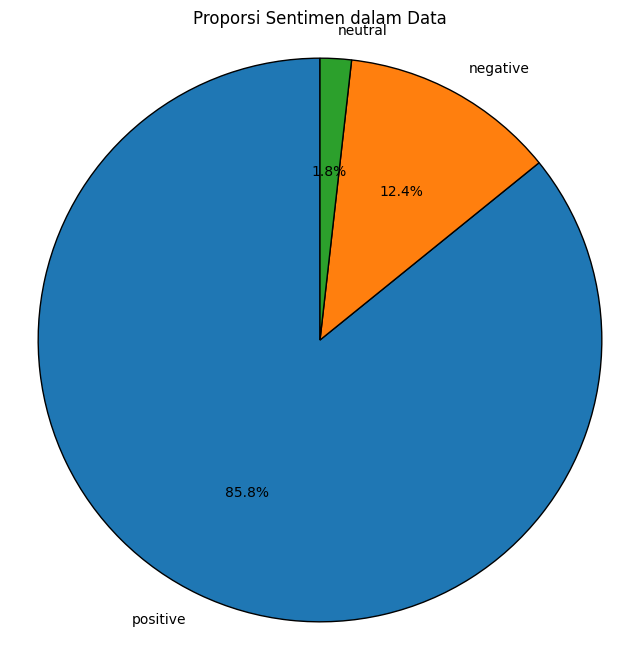

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Proporsi Sentimen dalam Data')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
output_file_name = 'dataset_pizza_sentiment.xlsx'
df.to_excel(output_file_name, index=False)
print(f"DataFrame berhasil diekspor ke '{output_file_name}' dengan keseluruhan fitur.")

DataFrame berhasil diekspor ke 'dataset_pizza_sentiment.xlsx' dengan keseluruhan fitur.


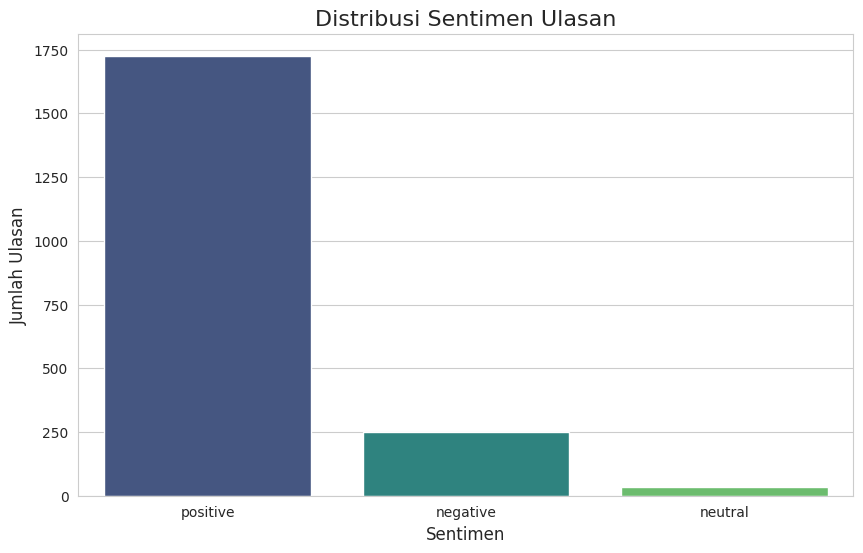

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
# Addressing the FutureWarning: Assign 'x' to 'hue' and set legend=False
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index, palette='viridis', legend=False)
plt.title('Distribusi Sentimen Ulasan', fontsize=16)
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()